# 02 — Judge Analysis

Judge score distributions and favoritism patterns across captions.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../scores.db')

# Only raw scores have a named judge
raw = pd.read_sql(
    "SELECT s.*, p.class_code, p.performance_date, p.ensemble_name "
    "FROM scores s JOIN performances p ON s.performance_key = p.performance_key "
    "WHERE s.role = 'raw_score'",
    conn,
)
print(raw.shape)

(36704, 12)


In [2]:
# Top judges by number of appearances
raw['judge'].value_counts().head(20)

judge
B. Kuhn          2216
C. Heiny         1678
A. Greene        1528
J. Dwyer         1378
J. Davila        1216
J. Harvey        1178
T. Rarick        1126
S. Collins       1020
R. Hardin         976
O. Carmenates     964
M. Leitzke        956
F. Miller         936
G. Fugett         814
B. Jones          780
D. Bryan          768
R. Ulibarri       740
J. Kennedy        738
M. McIntosh       676
M. Stevens        674
K. Bell           644
Name: count, dtype: int64

In [3]:
# Mean score per judge (judges with ≥30 raw scores)
judge_stats = raw.groupby('judge')['score'].agg(['mean', 'std', 'count'])
judge_stats = judge_stats[judge_stats['count'] >= 30].sort_values('mean', ascending=False)
judge_stats.head(20)

,mean,std,count
judge,,,
C. Hestin,89.526316,4.287886,76
M. Waymire,89.116071,5.278594,56
C. Rapacki,87.824324,3.623962,74
M. Gaines,87.734277,5.322204,318
R. Hardimon,87.170139,4.732038,144
P. Furnari,87.102564,4.963084,78
M. McIntosh,86.547337,7.370209,676
D. McCarthy,86.537829,5.339255,304
T. Fairbanks,86.492021,6.643817,188


/var/folders/qb/bbss79y57ts68fdmm95lb73w0000gn/T/ipykernel_55731/1588859100.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


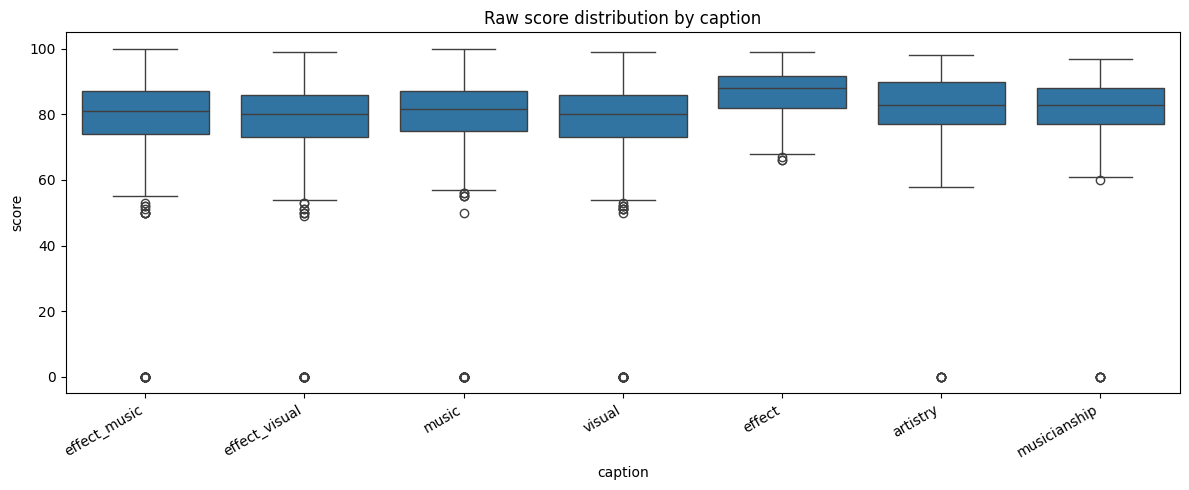

In [4]:
# Distribution by caption
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=raw, x='caption', y='score', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('Raw score distribution by caption')
plt.tight_layout()

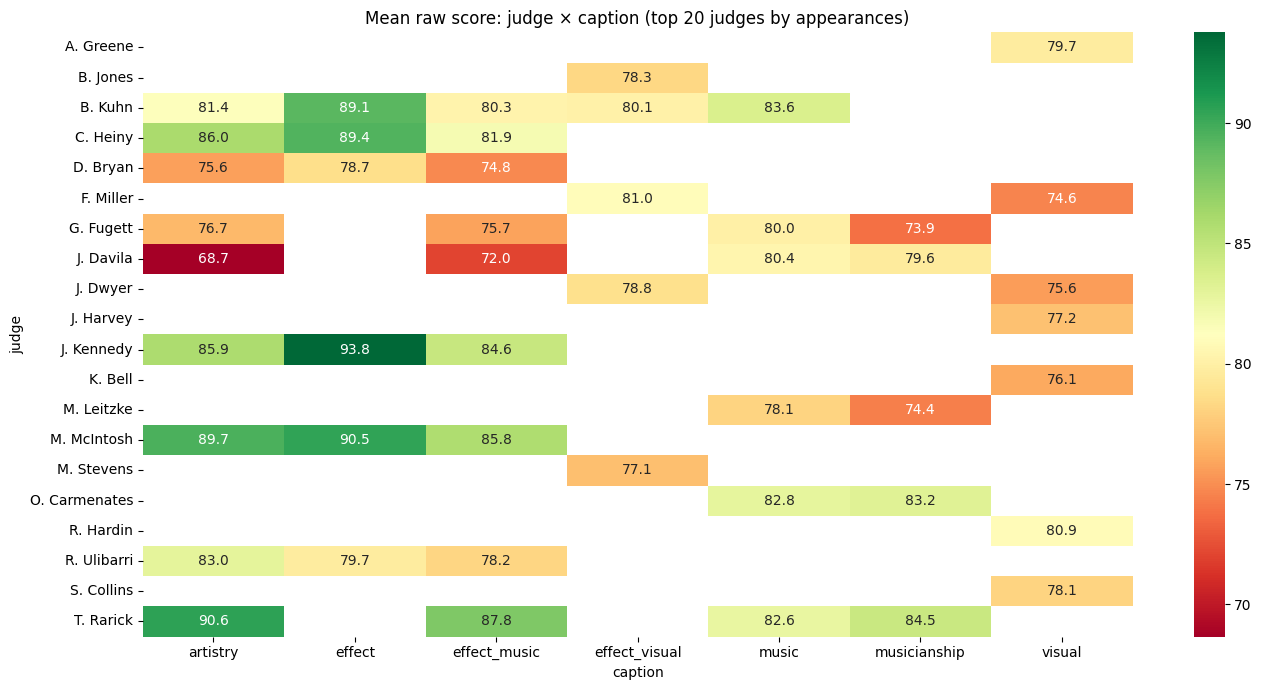

In [5]:
# Judge mean scores per caption (pivot heatmap, top 20 judges)
top_judges = raw['judge'].value_counts().head(20).index
pivot = (
    raw[raw['judge'].isin(top_judges)]
    .groupby(['judge', 'caption'])['score']
    .mean()
    .unstack(fill_value=float('nan'))
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax)
ax.set_title('Mean raw score: judge × caption (top 20 judges by appearances)')
plt.tight_layout()